# BBC News Classification with Cohere Embeddings

## Setup
Install deps, import libraries, configure key & paths.

In [22]:
# Install once
# !pip install cohere pandas scikit-learn numpy
# %pip install cohere
# %pip install python-dotenv

In [ ]:
# with open(".env", "w") as f:
#     f.write("COHERE_API_KEY=\n")


In [ ]:
import os, time, json, pickle
import numpy as np
import pandas as pd
import cohere
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# --- CONFIG ---
load_dotenv(r"\.env", override=True)
COHERE_API_KEY = os.getenv("COHERE_API_KEY")
DATA_PATH      = "bbc_news_full.csv"   # put the csv next to this notebook
EMBED_MODEL    = "embed-english-v3.0"
BATCH_SIZE     = 100
WAIT_SECONDS   = 60                    # stay under trial rate limit
TEST_SIZE      = 200                   # small run
RANDOM_STATE   = 0
BATCH_DIR      = "embed_batches"       # per-batch results saved here

os.makedirs(BATCH_DIR, exist_ok=True)
co = cohere.Client(COHERE_API_KEY)


In [25]:
# from google.colab import files
# uploaded = files.upload()  # drag & drop bbc_news_full.csv

## 1. Load data and Spliting

In [43]:
df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print(df['label_text'].value_counts())

# 2 per class = training
train_df = (df.groupby('label_text', group_keys=False)
              .apply(lambda g: g.sample(20, random_state=RANDOM_STATE)))

# remaining pool, then take a stratified sample of TEST_SIZE
pool = df.drop(train_df.index)
test_df, _ = train_test_split(
    pool, train_size=TEST_SIZE,
    stratify=pool['label_text'], random_state=RANDOM_STATE)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print("train:", train_df.shape, " test:", test_df.shape)
train_df.head(2)

shape: (2225, 3)
label_text
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64
train: (100, 3)  test: (200, 3)


C:\Users\hp\AppData\Local\Temp\ipykernel_11500\314186192.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(20, random_state=RANDOM_STATE)))


,text,label,label_text
0,saudi investor picks up the savoy london s fam...,1,business
1,mg rover china tie-up delayed mg rover s pro...,1,business


In [44]:
test_df['label_text'].value_counts()

label_text
sport            46
business         46
politics         37
tech             36
entertainment    35
Name: count, dtype: int64

## 2. Embed in batches of 100 (60s waits, saved per batch)

In [45]:
def embed_batch(texts, input_type):
    """Call Cohere embed for one batch."""
    resp = co.embed(texts=texts, model=EMBED_MODEL, input_type=input_type)
    return np.array(resp.embeddings)

def embed_in_batches(texts, input_type, tag):
    all_vecs = []
    n = len(texts)
    for i in range(0, n, BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]
        batch_idx = i // BATCH_SIZE
        print(f"[{tag}] batch {batch_idx+1} | docs {i}..{i+len(batch)-1}")

        vecs = embed_batch(batch, input_type)
        all_vecs.append(vecs)

        # save this batch to disk
        out = os.path.join(BATCH_DIR, f"{tag}_batch_{batch_idx:03d}.npy")
        np.save(out, vecs)
        print(f"  saved {out}  shape={vecs.shape}")

        # wait before next batch (skip after the last one)
        if i + BATCH_SIZE < n:
            print(f"  sleeping {WAIT_SECONDS}s...")
            time.sleep(WAIT_SECONDS)

    return np.vstack(all_vecs)

# training texts — tiny, one batch
X_train = embed_in_batches(train_df['text'].tolist(),
                           input_type='search_document', tag='train')
y_train = train_df['label_text'].values

# test texts — batches of 100 with 60s waits
X_test  = embed_in_batches(test_df['text'].tolist(),
                           input_type='search_document', tag='test')
y_test  = test_df['label_text'].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)

[train] batch 1 | docs 0..99
  saved embed_batches\train_batch_000.npy  shape=(100, 1024)
[test] batch 1 | docs 0..99
  saved embed_batches\test_batch_000.npy  shape=(100, 1024)
  sleeping 60s...
[test] batch 2 | docs 100..199
  saved embed_batches\test_batch_001.npy  shape=(100, 1024)
X_train: (100, 1024)  X_test: (200, 1024)


## Baseline — LogisticRegression on Cohere embeddings
This is the reference accuracy that the four methods below are compared against.

In [46]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# save predictions
out_df = test_df.copy()
out_df['predicted'] = y_pred
out_df.to_csv('predictions.csv', index=False)
print('saved predictions.csv')

saved predictions.csv


In [47]:
print(classification_report(y_test, y_pred, digits=3))

labels = sorted(df['label_text'].unique())

               precision    recall  f1-score   support

     business      1.000     0.957     0.978        46
entertainment      1.000     1.000     1.000        35
     politics      0.973     0.973     0.973        37
        sport      1.000     1.000     1.000        46
         tech      0.947     1.000     0.973        36

     accuracy                          0.985       200
    macro avg      0.984     0.986     0.985       200
 weighted avg      0.986     0.985     0.985       200

Confusion matrix (rows=true, cols=pred)


,business,entertainment,politics,sport,tech
business,44,0,1,0,1
entertainment,0,35,0,0,0
politics,0,0,36,0,1
sport,0,0,0,46,0
tech,0,0,0,0,36


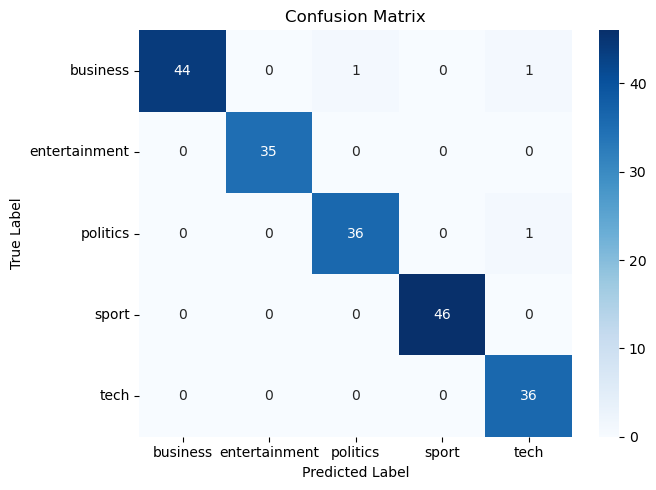

In [52]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(pd.DataFrame(cm, index=labels, columns=labels),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

###  Learning curve for the baseline

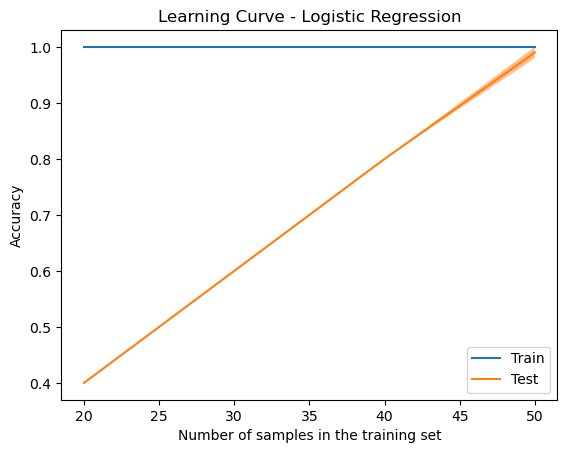

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np


cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)

LearningCurveDisplay.from_estimator(
    clf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.4, 1.0, 4),
    n_jobs=-1
)

plt.title("Learning Curve - Logistic Regression")
plt.show()

### ROC-AUC

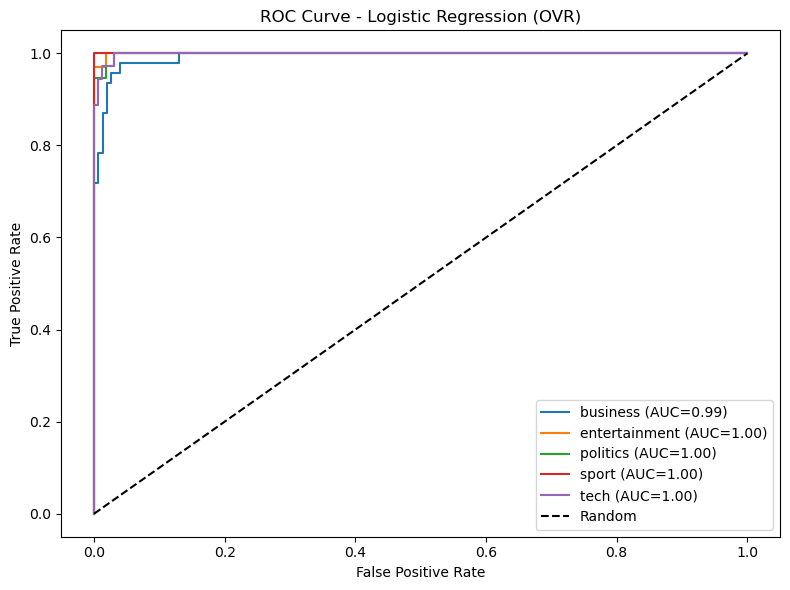

Macro ROC-AUC: 0.9979


In [49]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=clf.classes_)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(clf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (OVR)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Macro ROC-AUC: {roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'):.4f}")

In [51]:
from sklearn.metrics import accuracy_score
results = {'LogisticRegression (baseline)': accuracy_score(y_test, y_pred)}
print(results)

{'LogisticRegression (baseline)': 0.985}


## Method comparison

The four cells below re-use `X_train`, `X_test`, `y_train`, `y_test`, `train_df`, `test_df`,
and the `embed_batch` helper from above. Each method appends its accuracy to the
`results` dict; the final cell renders a sorted summary table.

## Method 1 — Embed + alternative classifier heads

Cohere embeddings, different classifiers. No extra API calls.

In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

heads = {
    'kNN (k=3, cosine)': KNeighborsClassifier(n_neighbors=3, metric='cosine'),
    'SVM (linear)'     : SVC(kernel='linear', C=1.0),
    'RandomForest'     : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

for name, model in heads.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    results[name] = acc
    print(f'--- {name}  acc={acc:.3f} ---')
    print(classification_report(y_test, pred, digits=3))

--- kNN (k=3, cosine)  acc=0.935 ---
               precision    recall  f1-score   support

     business      0.894     0.913     0.903        46
entertainment      0.966     0.800     0.875        35
     politics      0.902     1.000     0.949        37
        sport      0.938     0.978     0.957        46
         tech      1.000     0.972     0.986        36

     accuracy                          0.935       200
    macro avg      0.940     0.933     0.934       200
 weighted avg      0.937     0.935     0.934       200

--- SVM (linear)  acc=0.970 ---
               precision    recall  f1-score   support

     business      0.978     0.957     0.967        46
entertainment      0.946     1.000     0.972        35
     politics      0.944     0.919     0.932        37
        sport      1.000     1.000     1.000        46
         tech      0.972     0.972     0.972        36

     accuracy                          0.970       200
    macro avg      0.968     0.970     0.969  

## Method 2 — Embed + semantic similarity (zero training)

Embed a short description of each class, then assign each test doc to the class whose
embedding is most similar (cosine). No classifier is trained at all.

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

class_descriptions = {
    'business'     : 'business, finance, economy, companies, markets, and corporate news',
    'entertainment': 'entertainment, movies, music, celebrities, film, and television',
    'politics'     : 'politics, government, elections, policy, and political parties',
    'sport'        : 'sports, football, cricket, rugby, tennis, athletes, and matches',
    'tech'         : 'technology, computers, software, internet, gadgets, and science',
}
class_labels = list(class_descriptions.keys())
class_texts  = list(class_descriptions.values())

# one tiny embed call for the 5 class descriptions
class_vecs = embed_batch(class_texts, input_type='search_query')

sims      = cosine_similarity(X_test, class_vecs)
pred_sim  = np.array([class_labels[i] for i in sims.argmax(axis=1)])
acc_sim   = accuracy_score(y_test, pred_sim)
results['Semantic similarity (zero-shot)'] = acc_sim
print(f'acc = {acc_sim:.3f}')
print(classification_report(y_test, pred_sim, digits=3))

acc = 0.920
               precision    recall  f1-score   support

     business      0.880     0.957     0.917        46
entertainment      0.833     1.000     0.909        35
     politics      0.968     0.811     0.882        37
        sport      0.957     0.978     0.968        46
         tech      1.000     0.833     0.909        36

     accuracy                          0.920       200
    macro avg      0.928     0.916     0.917       200
 weighted avg      0.927     0.920     0.919       200



## Method 3 — Command chat prompting (few-shot)

For each test doc we ask the Command model to pick a class, using the training set as few shot.
docs as in-context examples. We batch calls with the same 60s wait pattern.

Note: this sends **one API call per test doc**, so it is slower and costs more than embed-based methods.

In [ ]:
CHAT_MODEL = 'command-a-03-2025'   # or 'command-r-08-2024' for cheaper/faster
CHAT_BATCH = 18                 # requests before each sleep (chat trial limit is 20/min)

labels_sorted = sorted(df['label_text'].unique())
preamble = (
    'You are a news classifier. Reply with ONLY one of these labels: '
    + ', '.join(labels_sorted) + '. No other words, no punctuation.'
)

# build few-shot examples from train_df
examples = []
for _, row in train_df.iterrows():
    examples.append(f'TEXT: {row["text"][:600]}\nLABEL: {row["label_text"]}')
few_shot = '\n\n'.join(examples)


def classify_one(text, max_retries=3):
    prompt = (few_shot + f'\n\nTEXT: {text[:1500]}\nLABEL:')
    for attempt in range(max_retries):
        try:
            resp = co.chat(model=CHAT_MODEL, message=prompt,
                           preamble=preamble, temperature=0)
            out = resp.text.strip().lower().split()[0]
            return out if out in labels_sorted else min(
                labels_sorted, key=lambda l: 0 if l in out else 1)
        except Exception as e:
            print(f'  retry {attempt+1}/{max_retries} after error: {type(e).__name__}')
            time.sleep(WAIT_SECONDS)
    raise RuntimeError('chat failed after retries — likely monthly quota exhausted')


preds_chat = []
for i, text in enumerate(test_df['text'].tolist()):
    preds_chat.append(classify_one(text))
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(test_df)} done')
    if (i + 1) % CHAT_BATCH == 0 and (i + 1) < len(test_df):
        print(f'  sleeping {WAIT_SECONDS}s...')
        time.sleep(WAIT_SECONDS)

preds_chat = np.array(preds_chat)
acc_chat = accuracy_score(y_test, preds_chat)
results['Command chat (few-shot)'] = acc_chat
print(f'acc = {acc_chat:.3f}')
print(classification_report(y_test, preds_chat, digits=3))


## Method 4 — Rerank as zero-shot classifier

For each test doc, treat every class description as a candidate "document" and the test
text as the "query." The highest rerank score wins. One API call per test doc.

In [63]:
try:
    resp = co.chat(model=CHAT_MODEL, message="hi", temperature=0)
    print("Call succeeded!")
except Exception as e:
    print(f"Remaining calls: {e.headers.get('x-trial-endpoint-call-remaining')}")
    print(f"Status code: {e.status_code}")
    print(f"Message: {e.body}")

Remaining calls: 17
Status code: 429
Message: {'id': 'd7acb0ae-d956-4061-96e3-c3163e109a36', 'message': "You are using a Trial key, which is limited to 1000 API calls / month. You can continue to use the Trial key for free or upgrade to a Production key with higher rate limits at 'https://dashboard.cohere.com/api-keys'. Contact us on 'https://discord.gg/XW44jPfYJu' or email us at support@cohere.com with any questions"}


In [56]:
# RERANK_MODEL = 'rerank-english-v3.0'
RERANK_MODEL = 'rerank-v3.5'
RERANK_BATCH = 8

rerank_docs = [
    'This is a news article about business, finance, the economy, companies, and markets.',
    'This is a news article about entertainment, movies, music, celebrities, and television.',
    'This is a news article about politics, government, elections, and political parties.',
    'This is a news article about sports, athletes, matches, football, cricket, or rugby.',
    'This is a news article about technology, computers, software, internet, and gadgets.',
]
# class_labels stays the same order: business, entertainment, politics, sport, tech

preds_rr = []
for i, text in enumerate(test_df['text'].tolist()):
    r = co.rerank(model=RERANK_MODEL,
                  query=text[:400],
                  documents=rerank_docs,
                  top_n=1)
    preds_rr.append(class_labels[r.results[0].index])
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(test_df)} done')
    if (i + 1) % RERANK_BATCH == 0 and (i + 1) < len(test_df):
        print(f'  sleeping {WAIT_SECONDS}s...')
        time.sleep(WAIT_SECONDS)

preds_rr = np.array(preds_rr)
acc_rr   = accuracy_score(y_test, preds_rr)
results['Rerank (zero-shot)'] = acc_rr
print(f'acc = {acc_rr:.3f}')
print(classification_report(y_test, preds_rr, digits=3))

  sleeping 60s...
  sleeping 60s...
  20/200 done
  sleeping 60s...
  sleeping 60s...
  40/200 done
  sleeping 60s...
  sleeping 60s...
  sleeping 60s...
  60/200 done
  sleeping 60s...
  sleeping 60s...
  80/200 done
  sleeping 60s...
  sleeping 60s...
  sleeping 60s...
  100/200 done
  sleeping 60s...
  sleeping 60s...
  120/200 done
  sleeping 60s...
  sleeping 60s...
  sleeping 60s...
  140/200 done
  sleeping 60s...
  sleeping 60s...
  160/200 done
  sleeping 60s...
  sleeping 60s...
  sleeping 60s...
  180/200 done
  sleeping 60s...
  sleeping 60s...
  200/200 done
acc = 0.875
               precision    recall  f1-score   support

     business      0.884     0.826     0.854        46
entertainment      0.756     0.971     0.850        35
     politics      0.886     0.838     0.861        37
        sport      0.956     0.935     0.945        46
         tech      0.906     0.806     0.853        36

     accuracy                          0.875       200
    macro avg      0.87

## Summary — all methods

In [57]:
summary = pd.DataFrame(
    [(name, f'{acc:.3f}') for name, acc in results.items()],
    columns=['method', 'accuracy']
).sort_values('accuracy', ascending=False).reset_index(drop=True)
summary.to_csv('method_comparison.csv', index=False)
summary

,method,accuracy
0,LogisticRegression (baseline),0.985
1,SVM (linear),0.970
2,RandomForest,0.940
3,"kNN (k=3, cosine)",0.935
4,Command chat (few-shot),0.930
5,Semantic similarity (zero-shot),0.920
6,Rerank (zero-shot),0.875


### Notes
- Trial keys are free but rate-limited (~100 embed calls/min). The 60s wait between batches of 100 keeps you safely under that.
- Per-batch `.npy` files are in `embed_batches/`
- Below ~5 docs/class, zero-shot methods (Rerank, SemSim) win. Above ~10-20 docs/class, embed + linear classifier wins. The crossover is the most important pattern in this whole experiment.
- Few-shot chat hits its ceiling around 3-5 examples per class. Past that, you're paying more (tokens, latency) for no gain — sometimes for slight degradation. Supervised classifiers on embeddings, by contrast, keep improving with more data.